# 04 - Grad-CAM Visualization

Grad-CAM shows *where* the model looks when it makes a prediction.
We compute gradients of the predicted class score w.r.t. the last conv layer —
regions with large gradients are what the model found most useful.

This helps us check if the model actually learned the pattern shapes,
or just picked up on background noise.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models, datasets

# checkpoints come from Drive, data from local /content/
try:
    from google.colab import drive
    drive.mount('/drive')
    CKPT_DIR    = Path('/drive/MyDrive/ECE176/checkpoints')
    RESULTS_DIR = Path('/content/results')
except ImportError:
    CKPT_DIR    = Path('.').resolve() / 'checkpoints'
    RESULTS_DIR = Path('.').resolve() / 'results'

SYNTHETIC_DIR = Path('/content/data/synthetic')
IMG_SIZE = 224
CLASS_NAMES = [
    'head_and_shoulders', 'double_top', 'descending_triangle',
    'inv_head_and_shoulders', 'double_bottom', 'ascending_triangle', 'no_pattern',
]
N_CLASSES = len(CLASS_NAMES)

os.makedirs(RESULTS_DIR / 'figures', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else
                       'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Device      : {device}')
print(f'Checkpoints : {CKPT_DIR}')


Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
Device      : cuda
Checkpoints : /drive/MyDrive/ECE176/checkpoints


In [2]:
class PatternCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES, dropout=0.5):
        super().__init__()
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            conv_block(3, 32), conv_block(32, 64), conv_block(64, 128),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128, 256),
            nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(256, n_classes),
        )
    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))


def build_resnet18(n_classes=N_CLASSES):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(512, n_classes)
    return m


cnn_model = PatternCNN().to(device)
cnn_model.load_state_dict(torch.load(CKPT_DIR / 'cnn_best.pt', map_location=device))
cnn_model.eval()

resnet_model = build_resnet18().to(device)
resnet_model.load_state_dict(torch.load(CKPT_DIR / 'resnet_best.pt', map_location=device))
resnet_model.eval()

print('Both models loaded!')


Both models loaded!


## Grad-CAM

Steps:
1. Hook the last conv layer to capture its output (feature maps) on forward pass
2. Hook it again to capture gradients on backward pass
3. Average-pool the gradients across spatial dims → per-channel importance weights
4. Weighted sum of feature maps → heatmap → resize to 224×224

In [3]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.fmaps = None
        self.grads = None
        self.h1 = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'fmaps', o.detach())
        )
        self.h2 = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'grads', go[0].detach())
        )

    def __call__(self, img_tensor, class_idx=None):
        self.model.zero_grad()
        out = self.model(img_tensor)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        out[0, class_idx].backward()

        weights = self.grads.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.fmaps).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, (IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

    def remove(self):
        self.h1.remove()
        self.h2.remove()


def make_overlay(img_tensor, cam, alpha=0.5):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img  = (img * std + mean).clip(0, 1)
    heat = cm.jet(cam)[:, :, :3]
    return (alpha * heat + (1 - alpha) * img).clip(0, 1), img


tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print('GradCAM ready')


GradCAM ready


## One Sample per Class

For each pattern class we pick one val image and show:
original → CNN heatmap → CNN overlay → ResNet heatmap → ResNet overlay

Good sign: heatmap highlights the actual pattern shape (peaks, valleys, triangles)

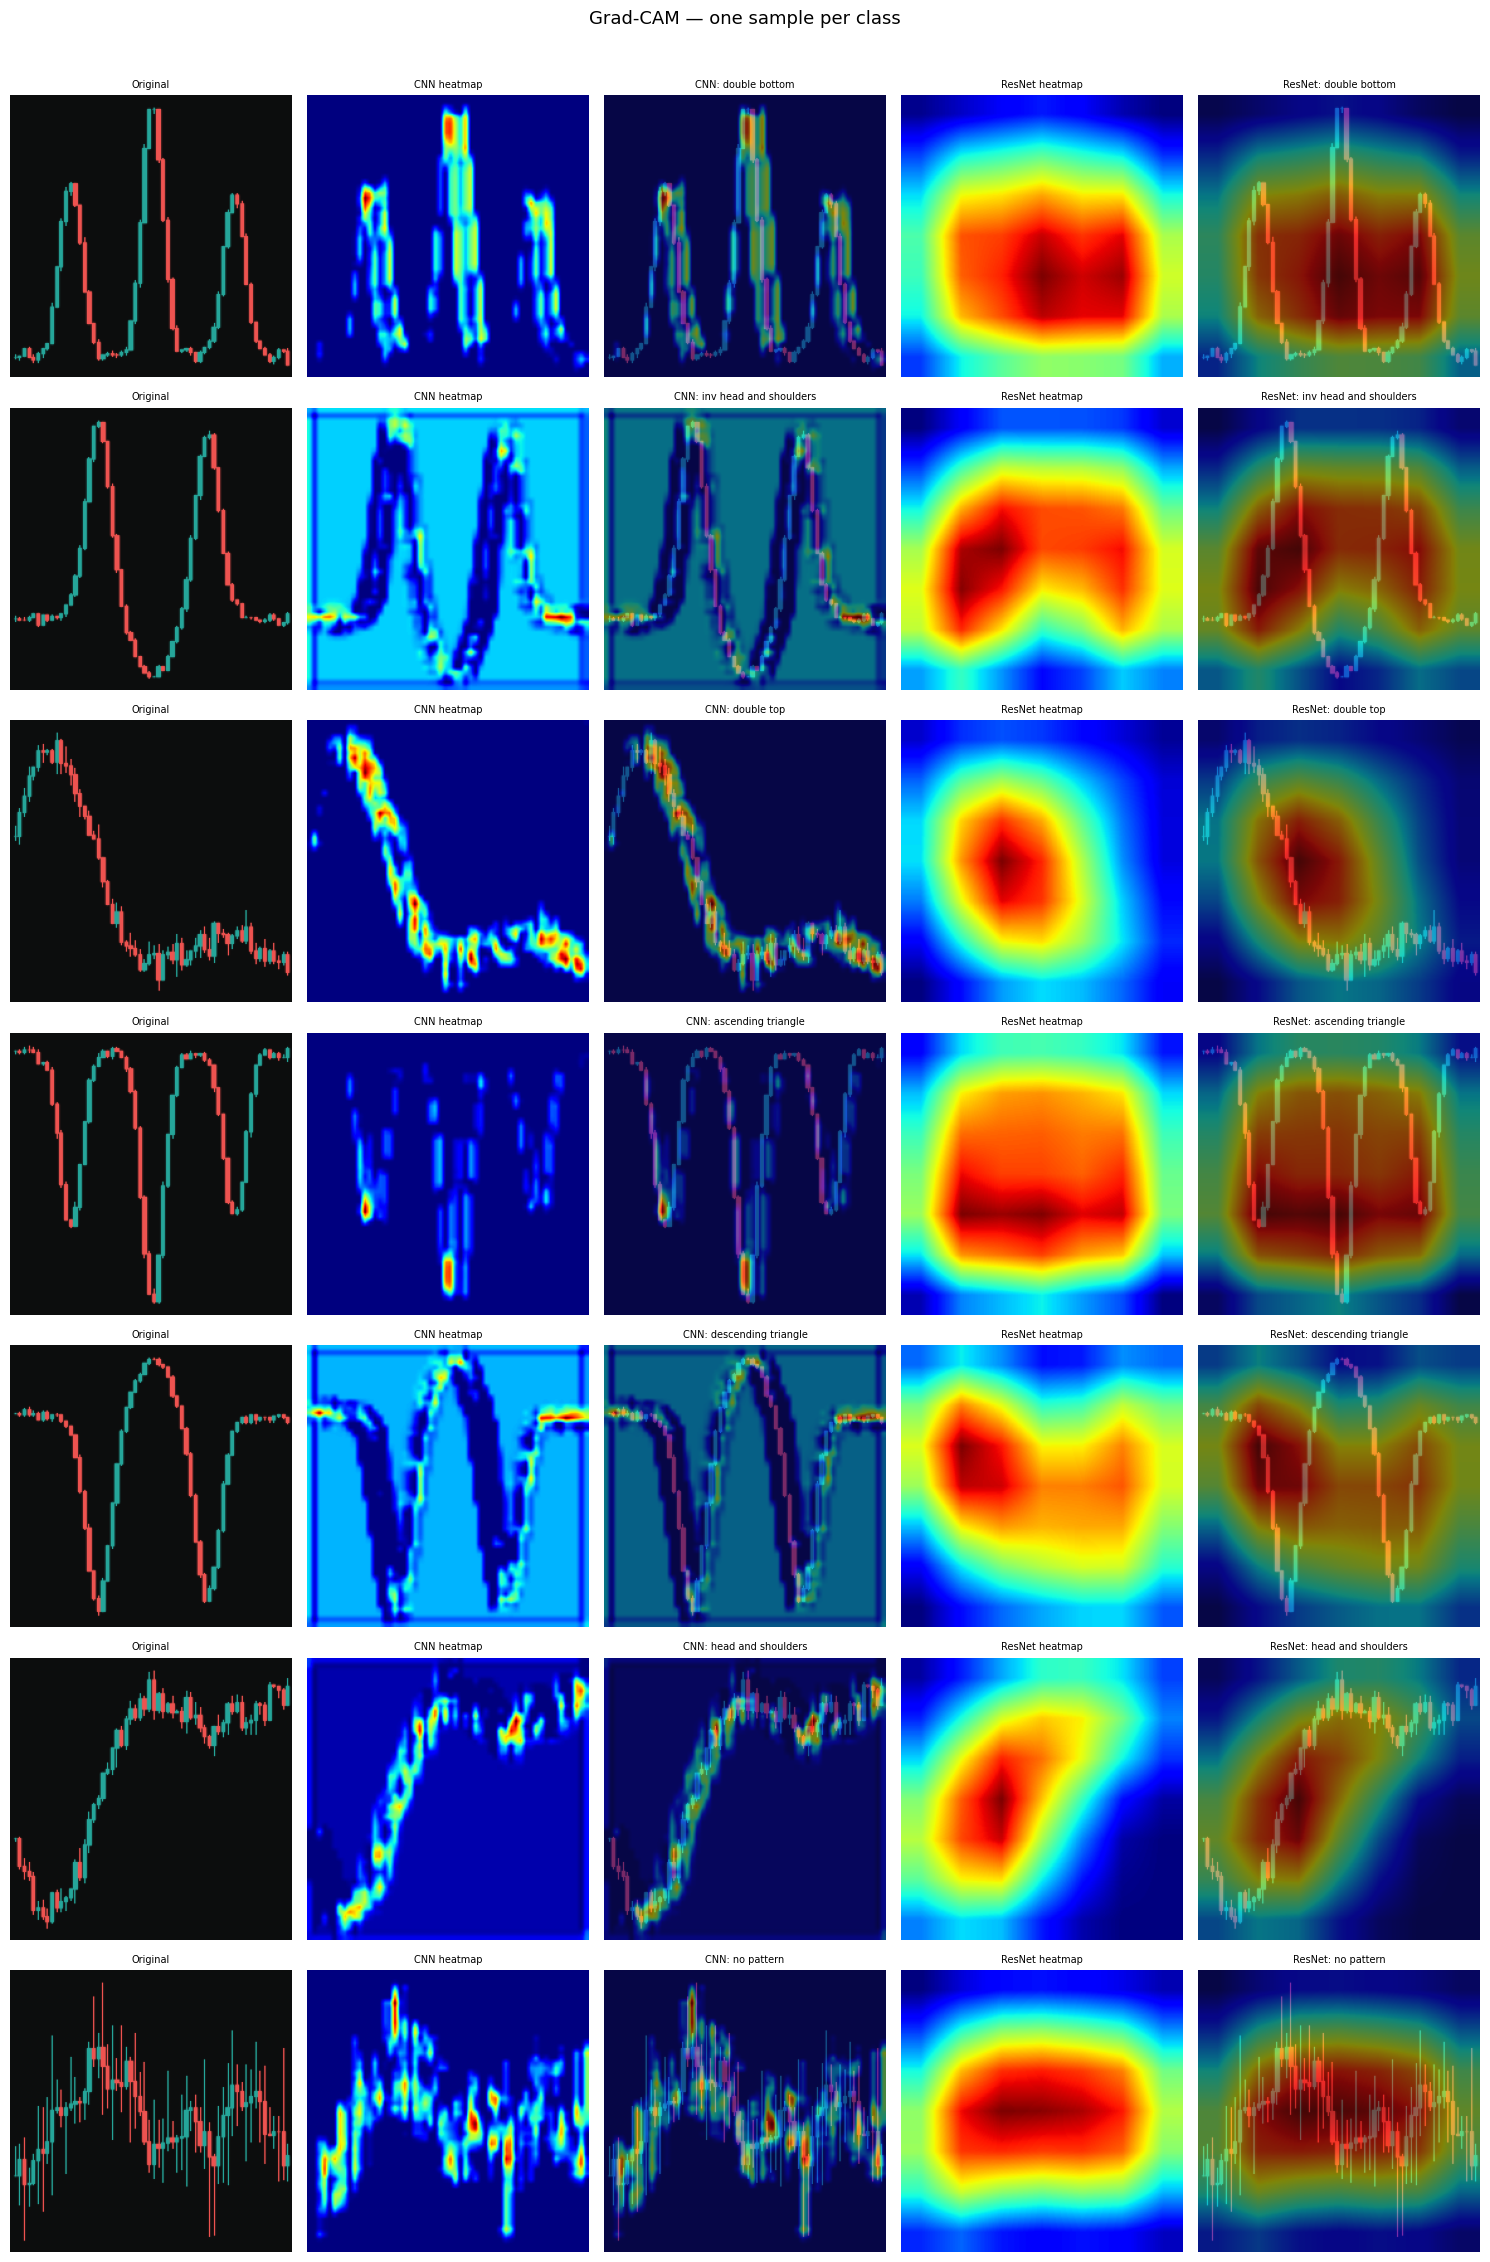

Saved gradcam_per_class.png


In [4]:
cnn_cam    = GradCAM(cnn_model,    cnn_model.features[-1][0])
resnet_cam = GradCAM(resnet_model, resnet_model.layer4[-1].conv2)

fig, axes = plt.subplots(len(CLASS_NAMES), 5, figsize=(15, 3.2 * len(CLASS_NAMES)))

for row, cls in enumerate(CLASS_NAMES):
    img_path   = sorted((SYNTHETIC_DIR / 'val' / cls).glob('*.png'))[0]
    img_tensor = tfm(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)

    cam_c, pred_c = cnn_cam(img_tensor)
    cam_r, pred_r = resnet_cam(img_tensor)

    ov_c, orig = make_overlay(img_tensor, cam_c)
    ov_r, _    = make_overlay(img_tensor, cam_r)

    for ax, data, title in zip(
        axes[row],
        [orig, cam_c, ov_c, cam_r, ov_r],
        ['Original',
         'CNN heatmap',
         f'CNN: {CLASS_NAMES[pred_c].replace("_"," ")}',
         'ResNet heatmap',
         f'ResNet: {CLASS_NAMES[pred_r].replace("_"," ")}'],
    ):
        ax.imshow(data, cmap='jet' if 'heatmap' in title else None)
        ax.set_title(title, fontsize=7)
        ax.axis('off')

    axes[row, 0].set_ylabel(cls.replace('_', '\n'), fontsize=7,
                             rotation=0, labelpad=55, va='center')

plt.suptitle('Grad-CAM — one sample per class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'gradcam_per_class.png', dpi=100, bbox_inches='tight')
plt.show()

cnn_cam.remove()
resnet_cam.remove()
print('Saved gradcam_per_class.png')


## Low-Confidence Predictions

Since the model hits 100% on synthetic val data, there are no wrong predictions to look at.
Instead we find the 4 images the model was **least confident** about — even if it got them right.
The heatmap shows what the model focused on when it was uncertain.


4 lowest-confidence predictions:
  conf=0.678  true=no_pattern  pred=no_pattern
  conf=0.744  true=head_and_shoulders  pred=head_and_shoulders
  conf=0.830  true=no_pattern  pred=no_pattern
  conf=0.878  true=double_bottom  pred=double_bottom


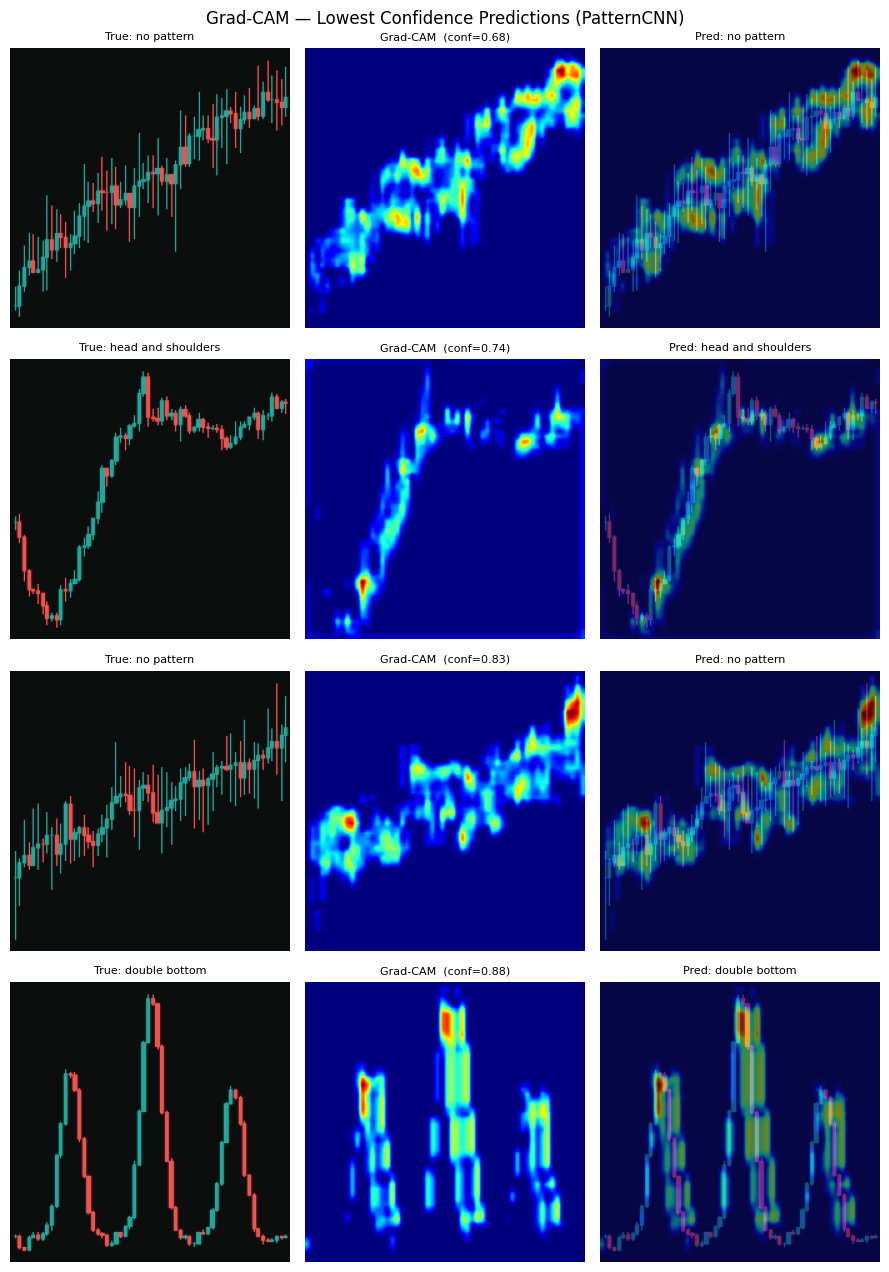

Saved gradcam_low_conf.png


In [5]:
# Since our model hits 100% on synthetic val, there are no misclassified samples.
# Instead we look at the predictions the model was LEAST confident about —
# these are the most informative for understanding model behaviour.

val_ds = datasets.ImageFolder(SYNTHETIC_DIR / 'val', transform=tfm)

scores = []  # (confidence, img_tensor, true_label, pred_label)
with torch.no_grad():
    for idx in range(len(val_ds)):
        img, true_lbl = val_ds[idx]
        img_t  = img.unsqueeze(0).to(device)
        probs  = torch.softmax(cnn_model(img_t), dim=1)
        conf, pred = probs.max(1)
        scores.append((conf.item(), img_t, true_lbl, pred.item()))

# sort by confidence ascending — least confident first
scores.sort(key=lambda x: x[0])
low_conf = scores[:4]

print('4 lowest-confidence predictions:')
for conf, _, true_lbl, pred_lbl in low_conf:
    print(f'  conf={conf:.3f}  true={CLASS_NAMES[true_lbl]}  pred={CLASS_NAMES[pred_lbl]}')

cnn_cam = GradCAM(cnn_model, cnn_model.features[-1][0])
fig, axes = plt.subplots(4, 3, figsize=(9, 13))

for row, (conf, img_tensor, true_lbl, pred_lbl) in enumerate(low_conf):
    cam, _ = cnn_cam(img_tensor, class_idx=pred_lbl)
    overlay, orig = make_overlay(img_tensor, cam)

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f'True: {CLASS_NAMES[true_lbl].replace("_"," ")}', fontsize=8)
    axes[row, 1].imshow(cam, cmap='jet')
    axes[row, 1].set_title(f'Grad-CAM  (conf={conf:.2f})', fontsize=8)
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f'Pred: {CLASS_NAMES[pred_lbl].replace("_"," ")}', fontsize=8)
    for ax in axes[row]: ax.axis('off')

plt.suptitle('Grad-CAM — Lowest Confidence Predictions (PatternCNN)', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'gradcam_low_conf.png', dpi=100, bbox_inches='tight')
plt.show()

cnn_cam.remove()
print('Saved gradcam_low_conf.png')


## Average Grad-CAM per Class

Averaging over 10 samples smooths out noise and shows the *typical* attention region
for each pattern class.

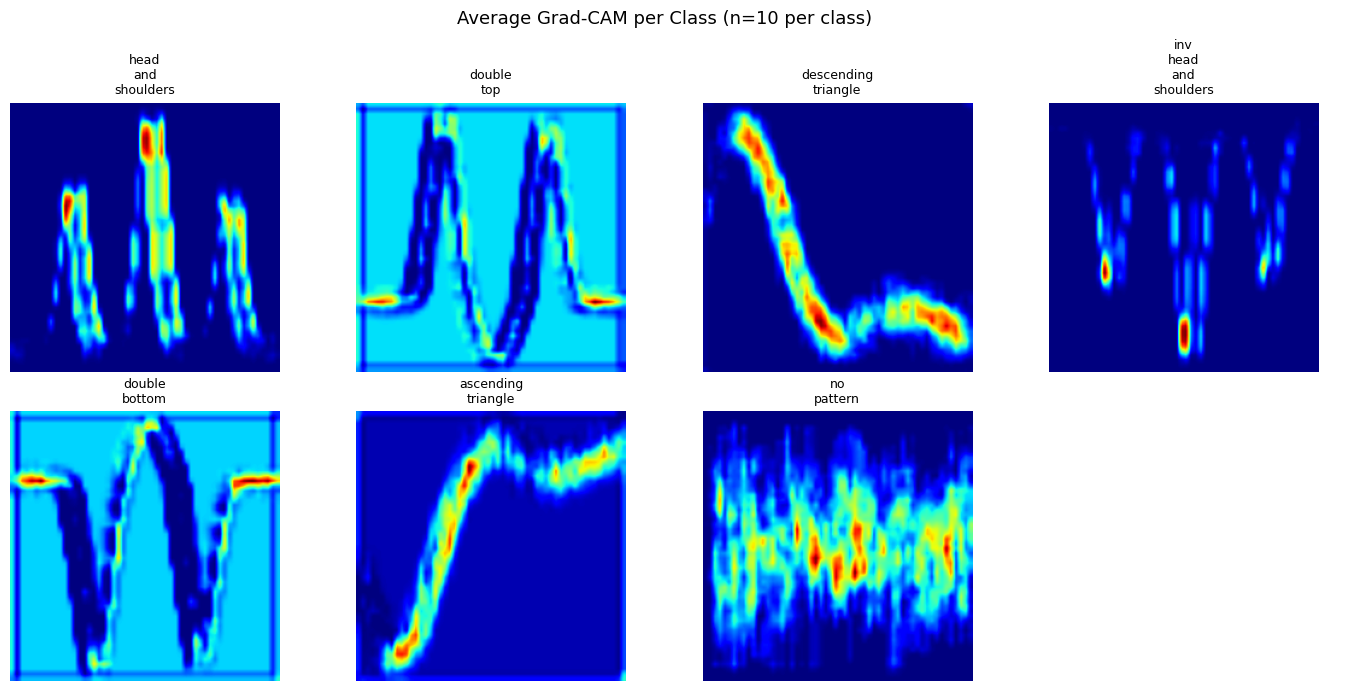

Saved gradcam_avg.png


In [6]:
N = 10
cnn_cam = GradCAM(cnn_model, cnn_model.features[-1][0])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    paths = sorted((SYNTHETIC_DIR / 'val' / cls).glob('*.png'))[:N]
    cams  = []
    for p in paths:
        img_t = tfm(Image.open(p).convert('RGB')).unsqueeze(0).to(device)
        cam, _ = cnn_cam(img_t)
        cams.append(cam)
    axes[i].imshow(np.mean(cams, axis=0), cmap='jet')
    axes[i].set_title(cls.replace('_', '\n'), fontsize=9)
    axes[i].axis('off')

axes[-1].axis('off')
plt.suptitle(f'Average Grad-CAM per Class (n={N} per class)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'gradcam_avg.png', dpi=120, bbox_inches='tight')
plt.show()

cnn_cam.remove()
print('Saved gradcam_avg.png')
